[Healthy] Using specific file: C:\Users\axelr\OneDrive\Escritorio\Proyecto3\beam_vibration_dataset\healthy\ALL0080\F0080CH1.CSV
[1-slight in C:\\Users\\axelr\\OneDrive\\Escritorio\\Proyecto3\\beam_vibration_dataset\\crack] Using specific file: C:\Users\axelr\OneDrive\Escritorio\Proyecto3\beam_vibration_dataset\crack\1-slight\slightdamage_2.5cm_beam10cm\ALL0005\F0005CH1.CSV
[2-moderate in C:\\Users\\axelr\\OneDrive\\Escritorio\\Proyecto3\\beam_vibration_dataset\\crack] Using specific file: C:\Users\axelr\OneDrive\Escritorio\Proyecto3\beam_vibration_dataset\crack\2-moderate\moderatedamage_4.5cm_beam10cm\ALL0020\F0020CH1.CSV
[3-severe in C:\\Users\\axelr\\OneDrive\\Escritorio\\Proyecto3\\beam_vibration_dataset\\crack] Using file: C:\Users\axelr\OneDrive\Escritorio\Proyecto3\beam_vibration_dataset\crack\3-severe\severedamage_1.5cm_beam10cm\ALL0000\F0000CH1.CSV
[1-slight in C:\\Users\\axelr\\OneDrive\\Escritorio\\Proyecto3\\beam_vibration_dataset\\wear] Using specific file: C:\Users\axelr\O

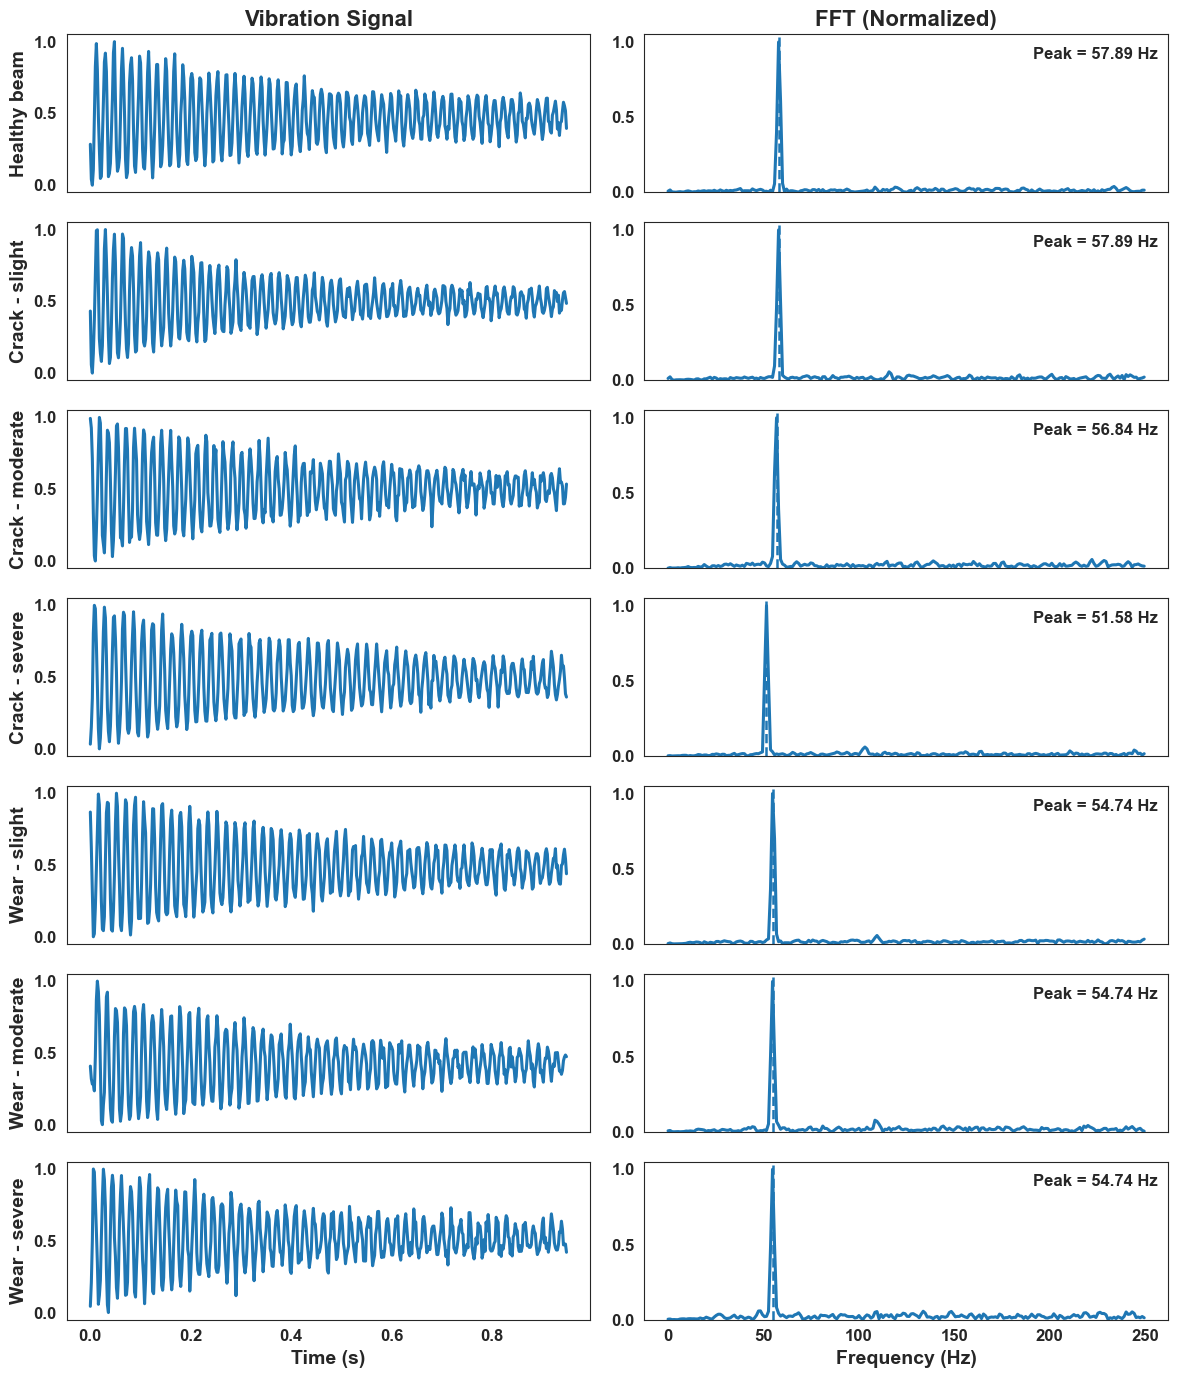

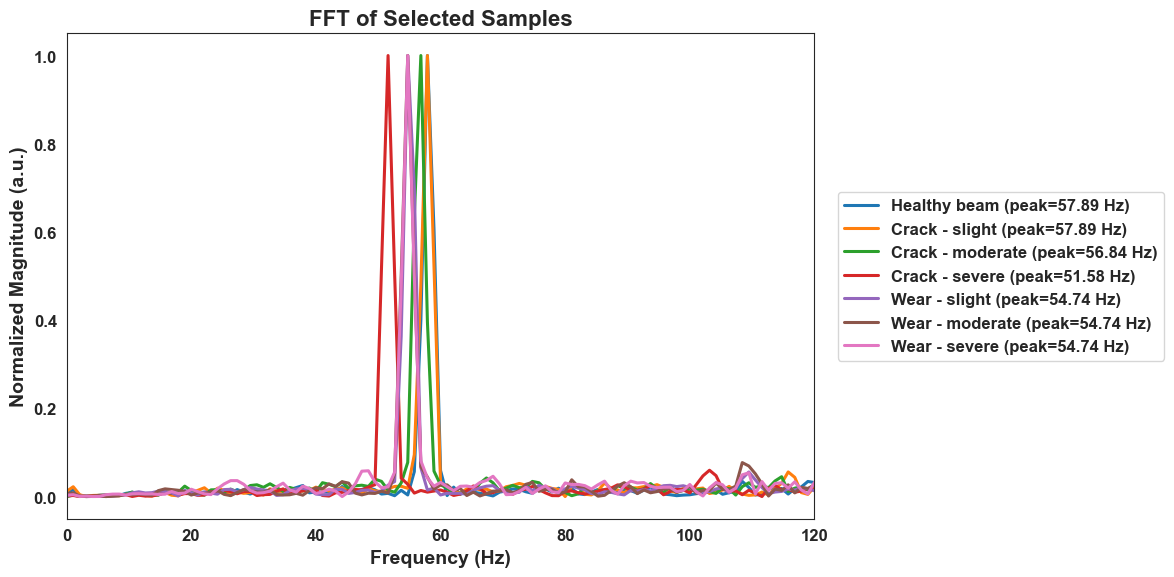

In [16]:
import re
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.signal import butter, filtfilt, detrend, windows
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------
# Global plot style (publication readability)
# ------------------------------------------------
plt.rcParams.update({
    "font.size": 14,
    "font.weight": "bold",
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.labelsize": 14,
    "axes.labelweight": "bold",
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})
sns.set_style("white")  # no grid

# ===================== BASE PATHS =====================
ROOT_HEALTHY = r"C:\\Users\\axelr\\OneDrive\\Escritorio\\Proyecto3\\beam_vibration_dataset\\healthy"
ROOT_CRACK = r"C:\\Users\\axelr\\OneDrive\\Escritorio\\Proyecto3\\beam_vibration_dataset\\crack"
ROOT_WEAR = r"C:\\Users\\axelr\\OneDrive\\Escritorio\\Proyecto3\\beam_vibration_dataset\\wear"

HIGHPASS_CUTOFF_HZ = 15.0
HIGHPASS_ORDER = 1

# ===================== TEKTRONIX UTILITIES =====================
def read_sampling_interval_from_header(csv_path: str):
    """Reads 'Sample Interval' from the Tektronix header (s)."""
    try:
        with open(csv_path, 'r', encoding='utf-8', errors='ignore') as f:
            for _ in range(80):
                line = f.readline()
                if not line:
                    break
                if "Sample Interval" in line:
                    m = re.search(r'([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)', line)
                    if m:
                        return float(m.group(1))
    except Exception:
        pass
    return None

def load_tektronix_csv_DE(csv_path: str):
    """Returns (t, v) using columns D (time) and E (voltage)."""
    df = pd.read_csv(
        csv_path,
        header=None,
        engine="python",
        sep=r"[,\t;]",
        skip_blank_lines=True
    )
    if df.shape[1] < 5:
        df = pd.read_csv(csv_path, header=None)

    col_D = pd.to_numeric(df.iloc[:, 3], errors='coerce')
    col_E = pd.to_numeric(df.iloc[:, 4], errors='coerce')
    mask = (~col_D.isna()) & (~col_E.isna())
    return col_D[mask].to_numpy(), col_E[mask].to_numpy()

def compute_fs(t: np.ndarray, csv_path: str) -> float:
    dt_header = read_sampling_interval_from_header(csv_path)
    if dt_header and dt_header > 0:
        return 1.0 / dt_header
    dt = np.median(np.diff(t))
    return 1.0 / dt

# ===================== SIGNAL PROCESSING =====================
def butter_highpass_filter(
    x: np.ndarray,
    fs: float,
    fc: float = HIGHPASS_CUTOFF_HZ,
    order: int = HIGHPASS_ORDER
):
    b, a = butter(order, fc / (fs / 2), btype='highpass')
    return filtfilt(b, a, x)

def one_sided_fft(x: np.ndarray, fs: float):
    """
    One-sided FFT with Hann window and dimensionless normalization.
    Returns (freqs, mag).
    """
    x = detrend(x, type='linear')
    m = np.max(np.abs(x))
    if m > 0:
        x = x / m

    N = len(x)
    w = windows.hann(N, sym=False)
    X = np.fft.rfft(x * w)
    freqs = np.fft.rfftfreq(N, 1 / fs)
    scale = 2.0 / np.sum(w)
    mag = np.abs(X) * scale

    if mag.size > 0:
        mag[0] /= 2.0
    if (N % 2 == 0) and (mag.size > 1):
        mag[-1] /= 2.0

    return freqs, mag

def normalize_01(x: np.ndarray):
    """Normalizes a signal to [0, 1]."""
    x_min = np.min(x)
    x_max = np.max(x)
    if x_max > x_min:
        return (x - x_min) / (x_max - x_min)
    return np.zeros_like(x)

# ===================== SAMPLE EXTRACTION PER CLASS =====================
def extract_healthy_half(root_dir: str, all_index: int | None = None):
    root = Path(root_dir)
    if not root.exists():
        raise FileNotFoundError(f"Path does not exist: {root_dir}")

    if all_index is not None:
        folder = root / f"ALL{all_index:04d}"
        csv_path = folder / f"F{all_index:04d}CH1.CSV"
        if not csv_path.exists():
            raise FileNotFoundError(f"Specific file does not exist: {csv_path}")

        t, v = load_tektronix_csv_DE(str(csv_path))
        fs = compute_fs(t, str(csv_path))
        N = len(v)
        t_seg = t[:N // 2]
        v_seg = v[:N // 2]
        print(f"[Healthy] Using specific file: {csv_path}")
        return t_seg, v_seg, fs

    for idx in range(50, 100):
        folder = root / f"ALL{idx:04d}"
        if not folder.exists():
            continue

        csv_path = folder / f"F{idx:04d}CH1.CSV"
        if not csv_path.exists():
            continue

        t, v = load_tektronix_csv_DE(str(csv_path))
        fs = compute_fs(t, str(csv_path))
        N = len(v)
        t_seg = t[:N // 2]
        v_seg = v[:N // 2]
        print(f"[Healthy] Using file: {csv_path}")
        return t_seg, v_seg, fs

    raise RuntimeError("No valid healthy beam sample with two perturbations was found.")

def extract_damage_half(
    root_base: str,
    level: str,
    folder_name: str | None = None,
    all_index: int | None = None
):
    root = Path(root_base)
    level_dir = root / level
    if not level_dir.exists():
        raise FileNotFoundError(f"Path does not exist: {level_dir}")

    if folder_name is not None and all_index is not None:
        damage_folder = level_dir / folder_name
        subfolder = damage_folder / f"ALL{all_index:04d}"
        csv_path = subfolder / f"F{all_index:04d}CH1.CSV"
        if not csv_path.exists():
            raise FileNotFoundError(f"Specific file does not exist: {csv_path}")

        t, v = load_tektronix_csv_DE(str(csv_path))
        fs = compute_fs(t, str(csv_path))
        N = len(v)
        t_seg = t[:N // 2]
        v_seg = v[:N // 2]
        print(f"[{level} in {root_base}] Using specific file: {csv_path}")
        return t_seg, v_seg, fs

    # Search any subfolder ending in "_beam10cm"
    for damage_folder in sorted([p for p in level_dir.iterdir() if p.is_dir() and p.name.endswith("_beam10cm")]):
        for subfolder in sorted(damage_folder.glob("ALL*")):
            csv_path = subfolder / f"F{subfolder.name[3:]}CH1.CSV"
            if not csv_path.exists():
                continue

            t, v = load_tektronix_csv_DE(str(csv_path))
            fs = compute_fs(t, str(csv_path))
            N = len(v)
            t_seg = t[:N // 2]
            v_seg = v[:N // 2]
            print(f"[{level} in {root_base}] Using file: {csv_path}")
            return t_seg, v_seg, fs

    raise RuntimeError(f"No valid sample found for level '{level}' in {root_base}")

# ===================== PROCESS (RETURN DATA) =====================
def process_class(
    class_name: str,
    t_seg: np.ndarray,
    v_seg: np.ndarray,
    fs: float,
    pad_start_time: float = 0.55,
    pad_end_time: float = 1.0
):
    v_filt = butter_highpass_filter(v_seg, fs)

    pad_start = int(pad_start_time * fs)
    pad_end = int(pad_end_time * fs)

    n = len(v_filt)
    if n > (pad_start + pad_end + 10):
        v_use = v_filt[pad_start:n - pad_end]
    else:
        v_use = v_filt.copy()

    freqs, mag = one_sided_fft(v_use, fs)

    mag_max = float(np.max(mag)) if mag.size else 0.0
    mag_norm = (mag / mag_max) if mag_max > 0 else mag

    idx_max = int(np.argmax(mag)) if mag.size else 0
    f_peak = float(freqs[idx_max]) if freqs.size else np.nan

    v_norm = normalize_01(v_use)
    t_rel = np.arange(len(v_norm)) / fs

    return {
        "name": class_name,
        "fs": fs,
        "t": t_rel,
        "v01": v_norm,
        "freqs": freqs,
        "mag": mag,
        "mag_norm": mag_norm,
        "f_peak": f_peak
    }

# ===================== MAIN: PROCESS ALL CLASSES =====================
classes = [
    ("Healthy beam",      "healthy", None,          None,                              80),
    ("Crack - slight",    "crack",   "1-slight",    "slightdamage_2.5cm_beam10cm",     5),
    ("Crack - moderate",  "crack",   "2-moderate",  "moderatedamage_4.5cm_beam10cm",   20),
    ("Crack - severe",    "crack",   "3-severe",    None,                              10),
    ("Wear - slight",     "wear",    "1-slight",    "slightdamage_3.5cm_beam10cm",     2),
    ("Wear - moderate",   "wear",    "2-moderate",  None,                              10),
    ("Wear - severe",     "wear",    "3-severe",    "severedamage_3.5cm_beam10cm",     20),
]

results = []

for class_name, damage_type, level, specific_folder, all_idx in classes:
    if damage_type == "healthy":
        t_seg, v_seg, fs = extract_healthy_half(ROOT_HEALTHY, all_index=all_idx)
    elif damage_type == "crack":
        t_seg, v_seg, fs = extract_damage_half(
            ROOT_CRACK,
            level,
            folder_name=specific_folder,
            all_index=all_idx
        )
    elif damage_type == "wear":
        t_seg, v_seg, fs = extract_damage_half(
            ROOT_WEAR,
            level,
            folder_name=specific_folder,
            all_index=all_idx
        )
    else:
        continue

    out = process_class(class_name, t_seg, v_seg, fs)
    results.append(out)

# ===================== 1) BIG FIGURE WITH SUBPLOTS (time + FFT) =====================
n_classes = len(results)

fig, axes = plt.subplots(
    n_classes, 2,
    figsize=(12, 2.0 * n_classes),
    sharex="col"
)

# If n_classes == 1, axes may not be a matrix; enforce shape (n, 2)
if n_classes == 1:
    axes = np.array([axes])

for i, r in enumerate(results):
    ax_t = axes[i, 0]
    ax_f = axes[i, 1]

    # ---- Time (0-1)
    ax_t.plot(r["t"], r["v01"], linewidth=2.2)
    ax_t.set_ylabel(r["name"], fontweight="bold")
    ax_t.grid(False)

    if i == n_classes - 1:
        ax_t.set_xlabel("Time (s)", fontweight="bold")

    # ---- Normalized FFT (peak = 1)
    ax_f.plot(r["freqs"], r["mag_norm"], linewidth=2.2)
    ax_f.grid(False)

    ax_f.axvline(r["f_peak"], linestyle="--", linewidth=1.8)

    ax_f.text(
        0.98, 0.92,
        f"Peak = {r['f_peak']:.2f} Hz",
        transform=ax_f.transAxes,
        ha="right", va="top",
        fontsize=12,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.9)
    )

    if i == n_classes - 1:
        ax_f.set_xlabel("Frequency (Hz)", fontweight="bold")

# Column titles
axes[0, 0].set_title("Vibration Signal", fontweight="bold")
axes[0, 1].set_title("FFT (Normalized)", fontweight="bold")

# Common limits
for i in range(n_classes):
    axes[i, 0].set_ylim(-0.05, 1.05)
    axes[i, 1].set_ylim(0.0, 1.05)

plt.tight_layout()
plt.show()

# ===================== 2) SEPARATE FIGURE: FFT COMPARISON (all together) =====================
plt.figure(figsize=(12, 6))

for r in results:
    plt.plot(
        r["freqs"], r["mag_norm"],
        linewidth=2.2,
        label=f"{r['name']} (peak={r['f_peak']:.2f} Hz)"
    )

plt.title("FFT of Selected Samples", fontweight="bold")
plt.xlabel("Frequency (Hz)", fontweight="bold")
plt.ylabel("Normalized Magnitude (a.u.)", fontweight="bold")

plt.xlim(0, 120)

plt.grid(False)
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)

plt.tight_layout()
plt.show()

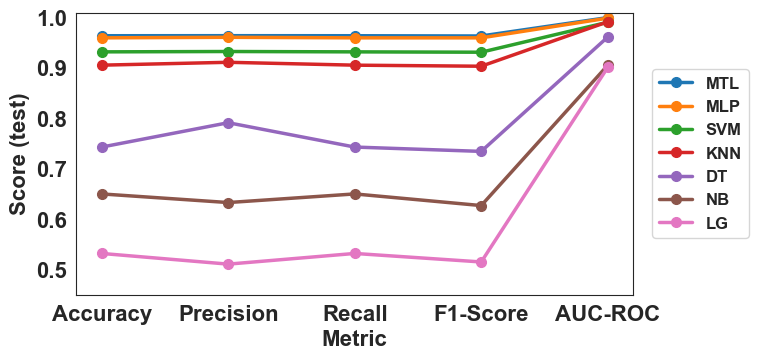

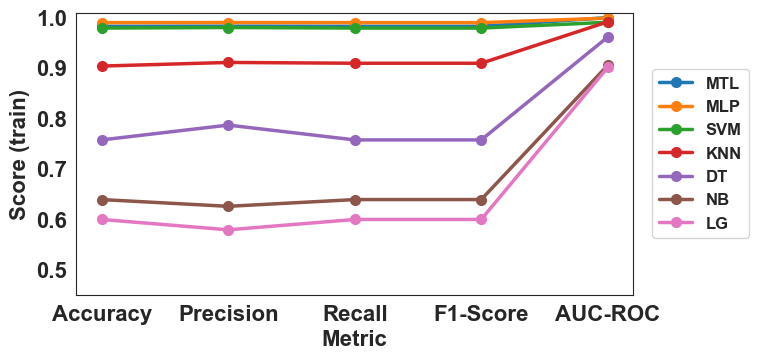

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------
# Global plot style (publication readability)
# ------------------------------------------------
plt.rcParams.update({
    "font.size": 20,
    "font.weight": "bold",
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.labelsize": 16,
    "axes.labelweight": "bold",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 12
})

sns.set_style("white")  # remove grid

# ============================================================
# 1) Data (test, train) by metric
# ============================================================
data = {
    "MTL": {
        "Accuracy":  (0.9639, 0.9826),
        "Precision": (0.9640, 0.9829),
        "Recall":    (0.9639, 0.9826),
        "F1-Score":  (0.9634, 0.9826),
        "AUC-ROC":   (0.9999, 0.9999),
    },
    "MLP": {
        "Accuracy":  (0.9597, 0.9899),
        "Precision": (0.9608, 0.9901),
        "Recall":    (0.9597, 0.9899),
        "F1-Score":  (0.9597, 0.9899),
        "AUC-ROC":   (0.9988, 0.9988),
    },
    "SVM": {
        "Accuracy":  (0.9319, 0.9791),
        "Precision": (0.9326, 0.9802),
        "Recall":    (0.9319, 0.9791),
        "F1-Score":  (0.9312, 0.9791),
        "AUC-ROC":   (0.9907, 0.9906),
    },
    "KNN": {
        "Accuracy":  (0.9055, 0.9037),
        "Precision": (0.9112, 0.9109),
        "Recall":    (0.9055, 0.9093),
        "F1-Score":  (0.9034, 0.9093),
        "AUC-ROC":   (0.9915, 0.9915),
    },
    "DT": {
        "Accuracy":  (0.7430, 0.7572),
        "Precision": (0.7913, 0.7866),
        "Recall":    (0.7430, 0.7572),
        "F1-Score":  (0.7344, 0.7572),
        "AUC-ROC":   (0.9613, 0.9613),
    },
    "NB": {
        "Accuracy":  (0.6500, 0.6388),
        "Precision": (0.6329, 0.6254),
        "Recall":    (0.6500, 0.6388),
        "F1-Score":  (0.6269, 0.6388),
        "AUC-ROC":   (0.9052, 0.9052),
    },
    "LG": {
        "Accuracy":  (0.5319, 0.5993),
        "Precision": (0.5107, 0.5788),
        "Recall":    (0.5319, 0.5993),
        "F1-Score":  (0.5150, 0.5993),
        "AUC-ROC":   (0.9010, 0.9009),
    }
}

metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC"]
models = list(data.keys())
x = np.arange(len(metrics))

# ============================================================
# 2) TEST figure
# ============================================================
plt.figure(figsize=(8, 4))

for model in models:
    y_test = [data[model][m][0] for m in metrics]
    plt.plot(
        x, y_test,
        marker="o",
        markersize=7,
        linewidth=2.5,
        label=model
    )

plt.xticks(x, metrics, fontweight="bold")
plt.ylim(0.45, 1.01)

plt.xlabel("Metric", fontweight="bold")
plt.ylabel("Score (test)", fontweight="bold")

plt.grid(False)
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)

plt.tight_layout()
plt.show()

# ============================================================
# 3) TRAIN figure
# ============================================================
plt.figure(figsize=(8, 4))

for model in models:
    y_train = [data[model][m][1] for m in metrics]
    plt.plot(
        x, y_train,
        marker="o",
        markersize=7,
        linewidth=2.5,
        label=model
    )

plt.xticks(x, metrics, fontweight="bold")
plt.ylim(0.45, 1.01)

plt.xlabel("Metric", fontweight="bold")
plt.ylabel("Score (train)", fontweight="bold")

plt.grid(False)
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)

plt.tight_layout()
plt.show()

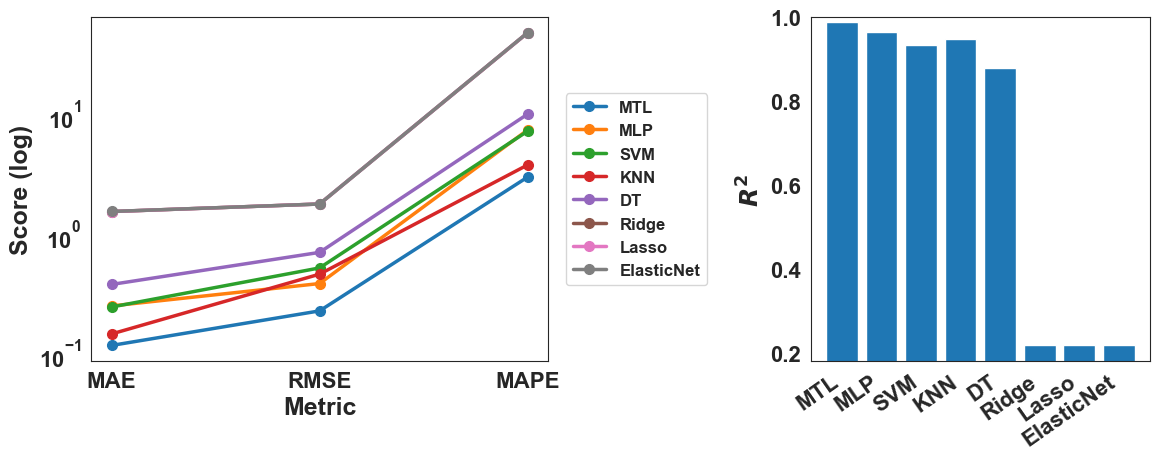

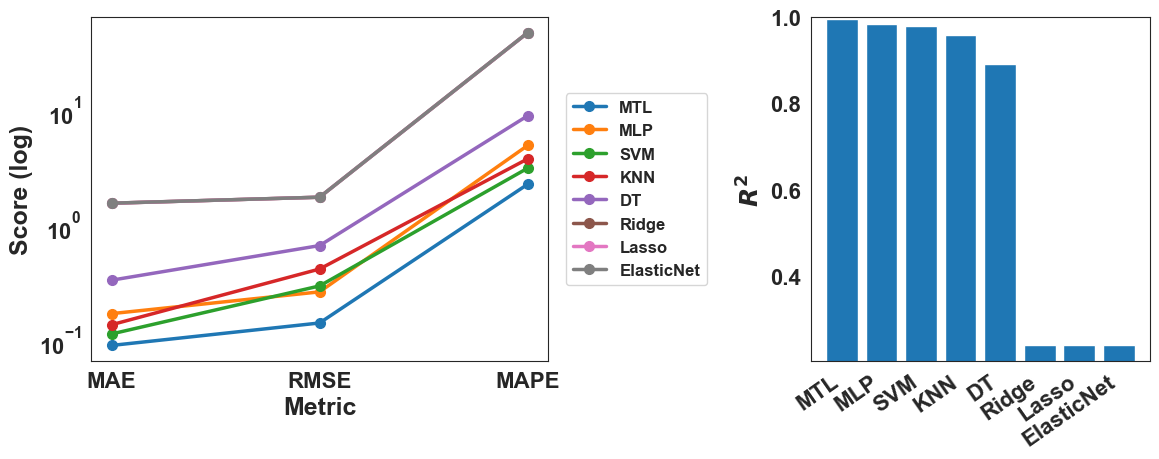

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------
# Global plot style (publication readability)
# ------------------------------------------------
plt.rcParams.update({
    "font.size": 20,
    "font.weight": "bold",
    "axes.titlesize": 18,
    "axes.titleweight": "bold",
    "axes.labelsize": 18,
    "axes.labelweight": "bold",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 12
})
sns.set_style("white")  # remove grid

# ============================================================
# Data (test, train) by metric — Regression Crack Task
# ============================================================
data = {
    "MTL": {
        "MAE":  (0.1156, 0.0892),
        "RMSE": (0.2254, 0.1400),
        "R2":   (0.9874, 0.9951),
        "MAPE": (2.99,   2.26),
    },
    "MLP": {
        "MAE":  (0.2479, 0.1688),
        "RMSE": (0.3822, 0.2612),
        "R2":   (0.9638, 0.9829),
        "MAPE": (7.43,   4.92),
    },
    "SVM": {
        "MAE":  (0.2428, 0.1123),
        "RMSE": (0.5168, 0.2943),
        "R2":   (0.9338, 0.9783),
        "MAPE": (7.26,   3.12),
    },
    "KNN": {
        "MAE":  (0.1443, 0.1351),
        "RMSE": (0.4582, 0.4130),
        "R2":   (0.9479, 0.9573),
        "MAPE": (3.78,   3.76),
    },
    "DT": {
        "MAE":  (0.3755, 0.3300),
        "RMSE": (0.6978, 0.6608),
        "R2":   (0.8794, 0.8909),
        "MAPE": (10.09,  8.92),
    },
    "Ridge": {
        "MAE":  (1.5348, 1.5441),
        "RMSE": (1.7761, 1.7428),
        "R2":   (0.2188, 0.2413),
        "MAPE": (48.53,  47.15),
    },
    "Lasso": {
        "MAE":  (1.5351, 1.5443),
        "RMSE": (1.7760, 1.7428),
        "R2":   (0.2189, 0.2413),
        "MAPE": (48.54,  47.16),
    },
    "ElasticNet": {
        "MAE":  (1.5370, 1.5461),
        "RMSE": (1.7753, 1.7429),
        "R2":   (0.2195, 0.2412),
        "MAPE": (48.62,  47.22),
    },
}

models = list(data.keys())
x_models = np.arange(len(models))
error_metrics = ["MAE", "RMSE", "MAPE"]

def plot_regression_two_panel(split_idx: int, split_name: str):
    x_err = np.arange(len(error_metrics))
    r2_vals = np.array([data[m]["R2"][split_idx] for m in models], dtype=float)

    fig, (ax1, ax2) = plt.subplots(
        1, 2, figsize=(12, 5),
        gridspec_kw={"width_ratios": [1.35, 1.0]}
    )

    # ---- Subplot 1: error metrics (lines by model) ----
    for m in models:
        y = np.array([data[m][metric][split_idx] for metric in error_metrics], dtype=float)
        y = np.clip(y, 1e-12, None)
        ax1.plot(
            x_err, y,
            marker="o",
            markersize=7,
            linewidth=2.5,
            label=m
        )

    ax1.set_xticks(x_err)
    ax1.set_xticklabels(error_metrics, fontweight="bold")
    # ax1.set_title(f"Error Metrics — {split_name}", fontweight="bold")
    ax1.set_xlabel("Metric", fontweight="bold")
    ax1.set_ylabel("Score (log)", fontweight="bold")
    ax1.set_yscale("log")

    ax1.grid(False)
    ax1.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)

    # ---- Subplot 2: R2 (bars) ----
    ax2.bar(x_models, r2_vals)
    ax2.set_xticks(x_models)
    ax2.set_xticklabels(models, rotation=35, ha="right", fontweight="bold")

    # ax2.set_title(r"$R^2$ — " + split_name, fontweight="bold")
    # ax2.set_xlabel("Model", fontweight="bold")
    ax2.set_ylabel(r"$R^2$", fontweight="bold")

    ax2.grid(False)

    r2_min, r2_max = float(np.min(r2_vals)), float(np.max(r2_vals))
    pad = 0.05 * (r2_max - r2_min) if (r2_max - r2_min) > 1e-9 else 0.02
    ax2.set_ylim(max(0.0, r2_min - pad), min(1.0, r2_max + pad))

    plt.tight_layout()
    plt.show()

# ===================== TEST =====================
plot_regression_two_panel(split_idx=0, split_name="TEST")

# ===================== TRAIN =====================
plot_regression_two_panel(split_idx=1, split_name="TRAIN")

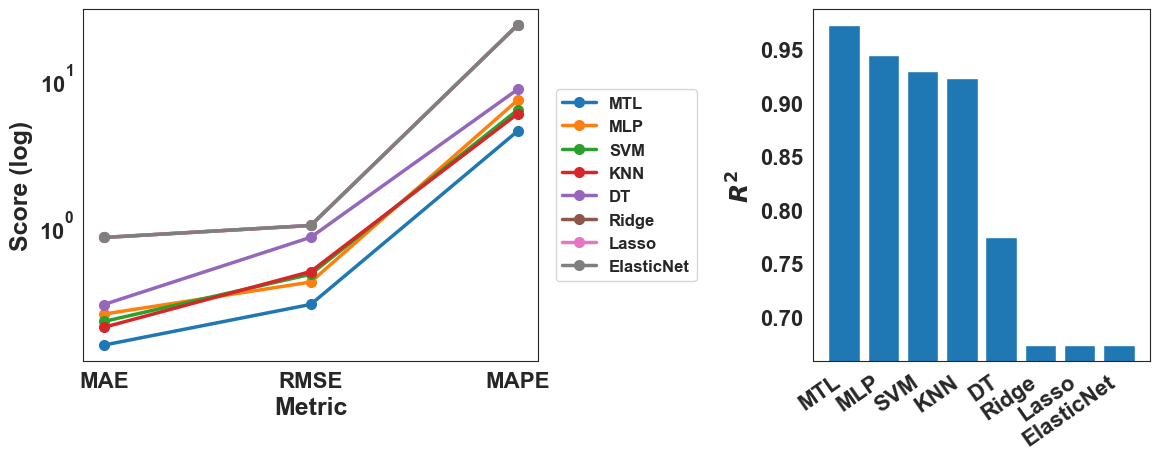

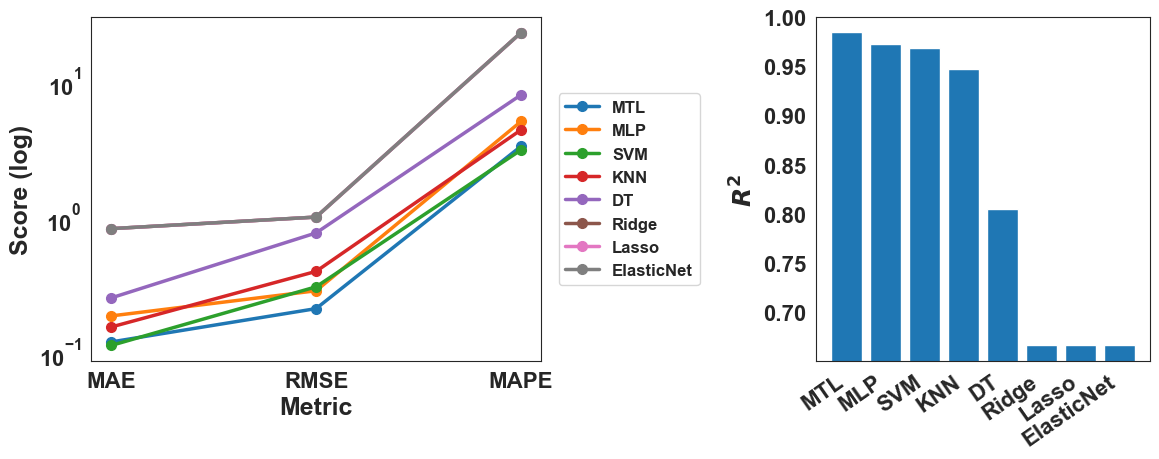

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------
# Global plot style (publication readability)
# ------------------------------------------------
plt.rcParams.update({
    "font.size": 20,
    "font.weight": "bold",
    "axes.titlesize": 18,
    "axes.titleweight": "bold",
    "axes.labelsize": 18,
    "axes.labelweight": "bold",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 12
})
sns.set_style("white")  # remove grid

# ============================================================
# Data (test, train) by metric — Regression Wear Task
# ============================================================
data = {
    "MTL": {
        "MAE":  (0.1520, 0.1192),
        "RMSE": (0.2875, 0.2099),
        "R2":   (0.9725, 0.9851),
        "MAPE": (4.34,   3.30),
    },
    "MLP": {
        "MAE":  (0.2470, 0.1854),
        "RMSE": (0.4081, 0.2842),
        "R2":   (0.9445, 0.9726),
        "MAPE": (7.05,   5.03),
    },
    "SVM": {
        "MAE":  (0.2200, 0.1123),
        "RMSE": (0.4611, 0.3039),
        "R2":   (0.9291, 0.9687),
        "MAPE": (6.05,   3.10),
    },
    "KNN": {
        "MAE":  (0.2008, 0.1536),
        "RMSE": (0.4810, 0.3949),
        "R2":   (0.9229, 0.9471),
        "MAPE": (5.69,   4.36),
    },
    "DT": {
        "MAE":  (0.2870, 0.2517),
        "RMSE": (0.8225, 0.7585),
        "R2":   (0.7746, 0.8052),
        "MAPE": (8.34,   7.90),
    },
    "Ridge": {
        "MAE":  (0.8204, 0.8154),
        "RMSE": (0.9898, 0.9928),
        "R2":   (0.6736, 0.6663),
        "MAPE": (22.86,  22.71),
    },
    "Lasso": {
        "MAE":  (0.8203, 0.8155),
        "RMSE": (0.9898, 0.9928),
        "R2":   (0.6736, 0.6663),
        "MAPE": (22.86,  22.71),
    },
    "ElasticNet": {
        "MAE":  (0.8204, 0.8159),
        "RMSE": (0.9901, 0.9929),
        "R2":   (0.6734, 0.6662),
        "MAPE": (22.88,  22.73),
    },
}

models = list(data.keys())
x_models = np.arange(len(models))
error_metrics = ["MAE", "RMSE", "MAPE"]

def plot_regression_two_panel(split_idx: int, split_name: str):
    x_err = np.arange(len(error_metrics))
    r2_vals = np.array([data[m]["R2"][split_idx] for m in models], dtype=float)

    fig, (ax1, ax2) = plt.subplots(
        1, 2, figsize=(12, 5),
        gridspec_kw={"width_ratios": [1.35, 1.0]}
    )

    # ---- Subplot 1: error metrics (lines by model) ----
    for m in models:
        y = np.array([data[m][metric][split_idx] for metric in error_metrics], dtype=float)
        y = np.clip(y, 1e-12, None)
        ax1.plot(
            x_err, y,
            marker="o",
            markersize=7,
            linewidth=2.5,
            label=m
        )

    ax1.set_xticks(x_err)
    ax1.set_xticklabels(error_metrics, fontweight="bold")
    # ax1.set_title(f"Error Metrics — {split_name}", fontweight="bold")
    ax1.set_xlabel("Metric", fontweight="bold")
    ax1.set_ylabel("Score (log)", fontweight="bold")
    ax1.set_yscale("log")

    ax1.grid(False)
    ax1.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)

    # ---- Subplot 2: R2 (bar chart) ----
    ax2.bar(x_models, r2_vals)
    ax2.set_xticks(x_models)
    ax2.set_xticklabels(models, rotation=35, ha="right", fontweight="bold")

    # ax2.set_title(r"$R^2$ — " + split_name, fontweight="bold")
    # ax2.set_xlabel("Model", fontweight="bold")
    ax2.set_ylabel(r"$R^2$", fontweight="bold")

    ax2.grid(False)

    r2_min, r2_max = float(np.min(r2_vals)), float(np.max(r2_vals))
    pad = 0.05 * (r2_max - r2_min) if (r2_max - r2_min) > 1e-9 else 0.02
    ax2.set_ylim(max(0.0, r2_min - pad), min(1.0, r2_max + pad))

    plt.tight_layout()
    plt.show()

# ===================== TEST =====================
plot_regression_two_panel(split_idx=0, split_name="TEST")

# ===================== TRAIN =====================
plot_regression_two_panel(split_idx=1, split_name="TRAIN")